<a href="https://colab.research.google.com/github/ektaggu/ECG-Heart-Disease-Project/blob/main/ECG-Signal-Classification/ECG_Signal_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# New path - Google Drive
path = '/content/drive/MyDrive/PTB_XL_Dataset/'

# Load labels
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

print("Database loaded!")
print(f"Total records: {len(Y)}")

Database loaded!
Total records: 21799


In [4]:
# Get diagnostic labels
def get_label(y_dic):
    keys = list(y_dic.keys())
    if len(keys) > 0:
        return keys[0]
    return 'UNKNOWN'

Y['label'] = Y.scp_codes.apply(get_label)

# Keep top 5 classes
top_classes = ['NORM', 'IMI', 'ASMI', 'LVH', 'LAFB']
Y_filtered = Y[Y['label'].isin(top_classes)]

print(f"Filtered records: {len(Y_filtered)}")
print(Y_filtered['label'].value_counts())

Filtered records: 15612
label
NORM    9514
IMI     2317
ASMI    1879
LVH     1212
LAFB     690
Name: count, dtype: int64


Signal shape: (15612, 1000, 12)
Labels shape: (15612,)


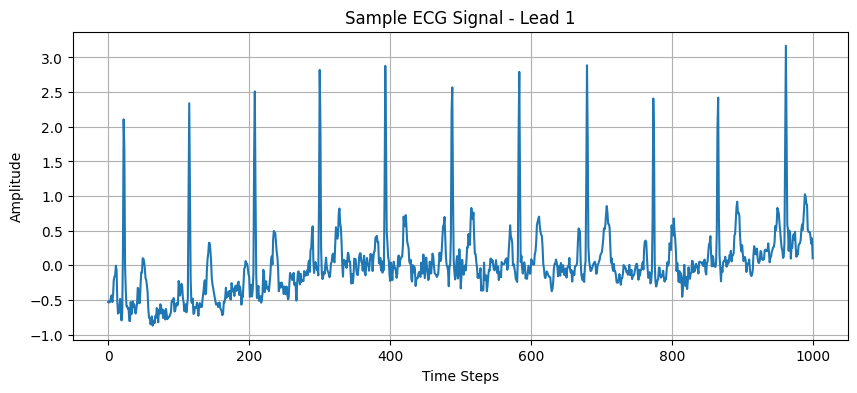

In [5]:
X = np.load('/content/drive/MyDrive/PTB_XL_Dataset/X_data.npy')
y = np.load('/content/drive/MyDrive/PTB_XL_Dataset/y_data.npy', allow_pickle=True)
print(f"Signal shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Sample ECG Signal Visualization
plt.figure(figsize=(10, 4))
plt.plot(X[0][:, 0])
plt.title("Sample ECG Signal - Lead 1")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

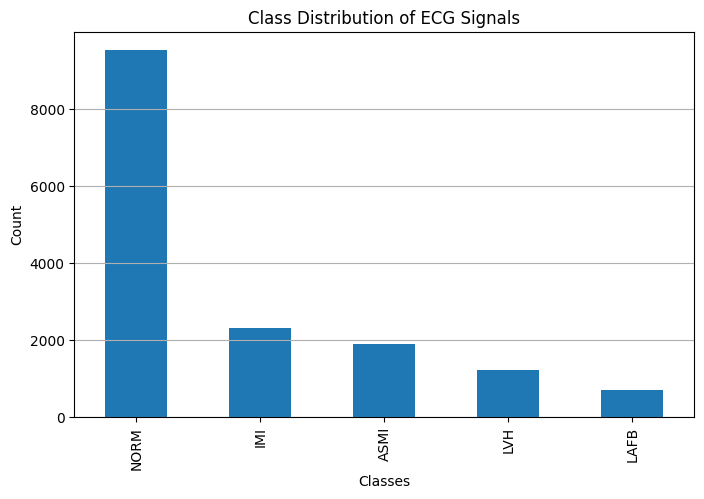

In [6]:
# Class Distribution
plt.figure(figsize=(8, 5))
pd.Series(y).value_counts().plot(kind='bar')
plt.title("Class Distribution of ECG Signals")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [7]:
import numpy as np
np.save('/content/drive/MyDrive/PTB_XL_Dataset/X_data.npy', X)
np.save('/content/drive/MyDrive/PTB_XL_Dataset/y_data.npy', y)
print("Data saved!")

Data saved!


In [8]:
from sklearn.utils import resample

min_samples = 690
balanced_X = []
balanced_y = []

for cls in ['NORM', 'IMI', 'ASMI', 'LVH', 'LAFB']:
    idx = np.where(y == cls)[0]
    idx_balanced = resample(idx, n_samples=min_samples, random_state=42)
    balanced_X.append(X[idx_balanced])
    balanced_y.append(y[idx_balanced])

X_balanced = np.concatenate(balanced_X)
y_balanced = np.concatenate(balanced_y)

print(f"Balanced dataset: {X_balanced.shape}")
print(f"Per class: {min_samples} each")

Balanced dataset: (3450, 1000, 12)
Per class: 690 each


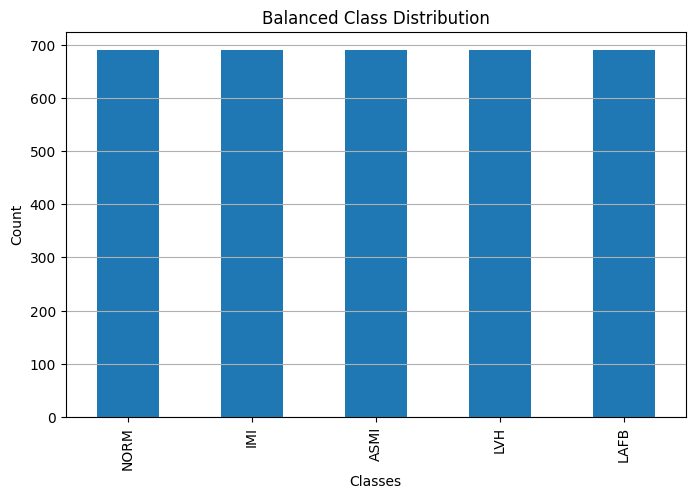

In [9]:
# Balanced Class Distribution
plt.figure(figsize=(8, 5))
pd.Series(y_balanced).value_counts().plot(kind='bar')
plt.title("Balanced Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y_balanced)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Classes: {le.classes_}")
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Classes: ['ASMI' 'IMI' 'LAFB' 'LVH' 'NORM']
Train: (2760, 1000, 12)
Test: (690, 1000, 12)


In [11]:
# Encoded Class Mapping
print("Encoded Label Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} --> {i}")

Encoded Label Mapping:
ASMI --> 0
IMI --> 1
LAFB --> 2
LVH --> 3
NORM --> 4


In [12]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(1000, 12)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(256, return_sequences=True),
    LSTM(128, return_sequences=False),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 998, 64)        │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 998, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 497, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 497, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 246, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 246, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 121, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 121, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 884,293 (3.37 MB)

 Trainable params: 883,141 (3.37 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [15]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)
print("Training complete!")

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.5261 - loss: 1.2165 - val_accuracy: 0.6536 - val_loss: 0.9960 - learning_rate: 0.0010
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6620 - loss: 0.9918 - val_accuracy: 0.5870 - val_loss: 1.0388 - learning_rate: 0.0010
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7094 - loss: 0.8371 - val_accuracy: 0.7145 - val_loss: 0.8239 - learning_rate: 0.0010
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7496 - loss: 0.7328 - val_accuracy: 0.6551 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7576 - loss: 0.7003 - val_accuracy: 0.7203 - val_loss: 0.7105 - learning_rate: 0.0010
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7982 - loss: 0.5863 - val_accuracy: 0.7420 - val_loss: 0.7448 - learning_rate: 0.0010
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7844 - loss: 0.6260 - val_ac

In [16]:
# Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8493 - loss: 0.5820
Test Accuracy: 84.93%
Test Loss: 0.5820


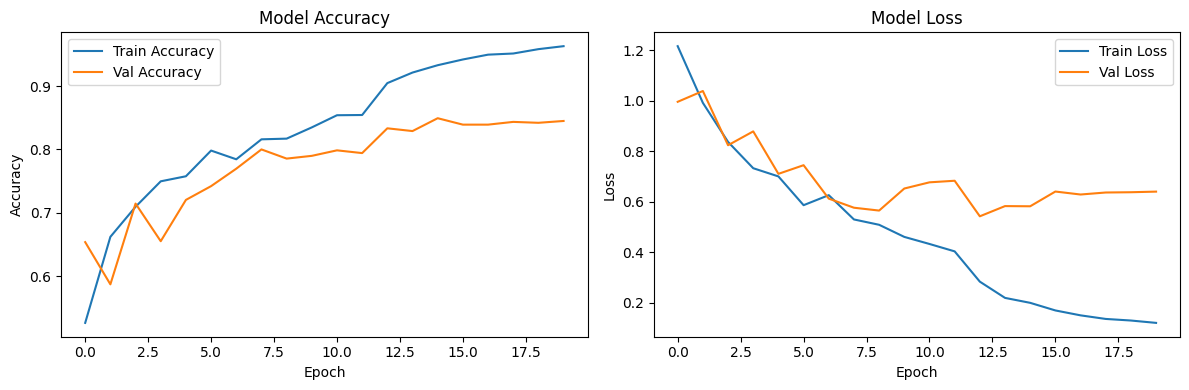

Graph saved!


In [17]:
# Training Graphs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_graphs_signal.png')
plt.show()
print("Graph saved!")

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


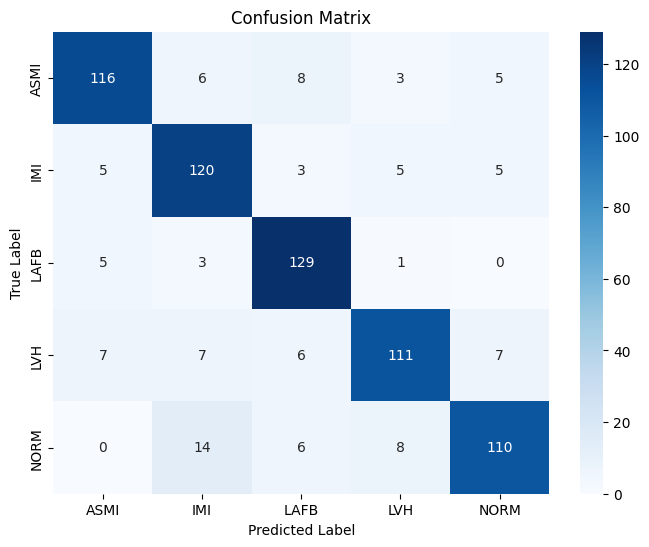

              precision    recall  f1-score   support

        ASMI       0.87      0.84      0.86       138
         IMI       0.80      0.87      0.83       138
        LAFB       0.85      0.93      0.89       138
         LVH       0.87      0.80      0.83       138
        NORM       0.87      0.80      0.83       138

    accuracy                           0.85       690
   macro avg       0.85      0.85      0.85       690
weighted avg       0.85      0.85      0.85       690



In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_signal.png')
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

In [20]:
# Per-Class Accuracy / F1 Summary
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_,
    output_dict=True
)

pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
ASMI,0.872180,0.840580,0.856089,138.000000
IMI,0.800000,0.869565,0.833333,138.000000
LAFB,0.848684,0.934783,0.889655,138.000000
LVH,0.867188,0.804348,0.834586,138.000000
NORM,0.866142,0.797101,0.830189,138.000000
accuracy,0.849275,0.849275,0.849275,0.849275
macro avg,0.850839,0.849275,0.848770,690.000000
weighted avg,0.850839,0.849275,0.848770,690.000000


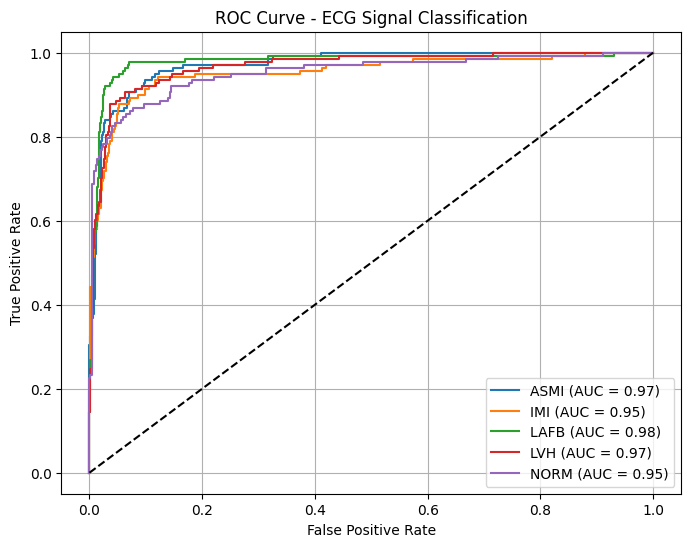

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert true labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ECG Signal Classification")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
model.save('ecg_signal_model_v2.h5')
print("Model saved!")

Model saved!
